## CSV 5: Duplicate Rows & Double-Counting Risk

**Description**  
A simulated CRM/data-warehouse merge issue where the same sales appear multiple times with non-identical duplicates differing by timestamps, minor text changes, or ingestion batches. Duplicate flags are intentionally absent.

**Purpose / What It Tests**
- Detection of duplicate records and keys
- Identification of revenue double-counting risk
- Transparency in deduplication warnings and strategies
- Correct KPI computation after deduplication
- Core black-box validation of analytical correctness


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(55)

BASE_ROWS = 2500
DUPLICATE_RATE = 0.25  # 25% duplicates

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date():
    return start_date + timedelta(days=random.randint(0, (end_date - start_date).days))

products = [
    (101, "CRM Pro", "Software"),
    (102, "Analytics Suite", "Software"),
    (201, "POS Terminal", "Hardware"),
]

regions = ["North America", "Europe", "Asia"]
salespeople = [f"Salesperson_{i}" for i in range(1, 12)]

rows = []

# ---------------------------
# Base clean transactions
# ---------------------------
for i in range(BASE_ROWS):
    product_id, product_name, category = random.choice(products)
    units = random.randint(1, 20)
    unit_price = random.randint(200, 1500)
    revenue = units * unit_price
    order_date = random_date()

    rows.append({
        "order_id": f"O-{500000+i}",
        "order_date": order_date,
        "customer_id": f"C-{random.randint(1000, 4000)}",
        "product_id": product_id,
        "product_name": product_name,
        "category": category,
        "units": units,
        "revenue": revenue,
        "salesperson": random.choice(salespeople),
        "region": random.choice(regions),
        "source_system": "CRM"
    })

df_base = pd.DataFrame(rows)

# ---------------------------
# Introduce duplicates
# ---------------------------
dup_rows = df_base.sample(frac=DUPLICATE_RATE, random_state=42)

dup_rows = dup_rows.copy()
dup_rows["order_date"] = dup_rows["order_date"] + pd.to_timedelta(
    np.random.randint(0, 2, size=len(dup_rows)), unit="D"
)
dup_rows["source_system"] = "DataWarehouse"

df_final = pd.concat([df_base, dup_rows], ignore_index=True)

df_final.to_csv("sales_duplicates.csv", index=False)
print("CSV generated: sales_duplicates.csv")
print("Total rows:", len(df_final))


CSV generated: sales_duplicates.csv
Total rows: 3125


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_duplicates.csv", parse_dates=["order_date"])

# Duplicate order_id detection
duplicate_orders = df["order_id"].duplicated().sum()
print("Duplicate order_id count:", duplicate_orders)

assert duplicate_orders > 0, "❌ No duplicate order_ids found"

# Revenue inflation check
raw_revenue = df["revenue"].sum()

dedup_revenue = (
    df.sort_values("order_date")
      .drop_duplicates(subset=["order_id"], keep="first")["revenue"]
      .sum()
)

inflation = raw_revenue - dedup_revenue

print("Raw revenue:", raw_revenue)
print("Deduplicated revenue:", dedup_revenue)
print("Revenue inflation due to duplicates:", inflation)

assert inflation > 0, "❌ Duplicate rows not inflating revenue"

# Confirm duplicates differ slightly
sample_dups = df[df["order_id"].duplicated(keep=False)].head(5)
print("Sample duplicated rows:\n", sample_dups)

print("✅ Duplicate & double-counting conditions validated.")


Duplicate order_id count: 625
Raw revenue: 27956255
Deduplicated revenue: 22336966
Revenue inflation due to duplicates: 5619289
Sample duplicated rows:
     order_id order_date customer_id  product_id     product_name  category  \
18  O-500018 2024-09-07      C-3412         102  Analytics Suite  Software   
25  O-500025 2023-07-20      C-3422         201     POS Terminal  Hardware   
29  O-500029 2024-12-10      C-3736         101          CRM Pro  Software   
43  O-500043 2024-04-07      C-2115         201     POS Terminal  Hardware   
44  O-500044 2023-10-21      C-1060         201     POS Terminal  Hardware   

    units  revenue    salesperson  region source_system  
18     14     7518  Salesperson_2    Asia           CRM  
25     16    12224  Salesperson_4  Europe           CRM  
29     14    12180  Salesperson_1    Asia           CRM  
43     19    24244  Salesperson_5    Asia           CRM  
44     15    10215  Salesperson_6  Europe           CRM  
✅ Duplicate & double-counting 

Gold Truth Analysis

Total Revenue (Deduplicated): 22336966
Duplicate Rate: 0.19999999999999996


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_49644\3088410879.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue"]


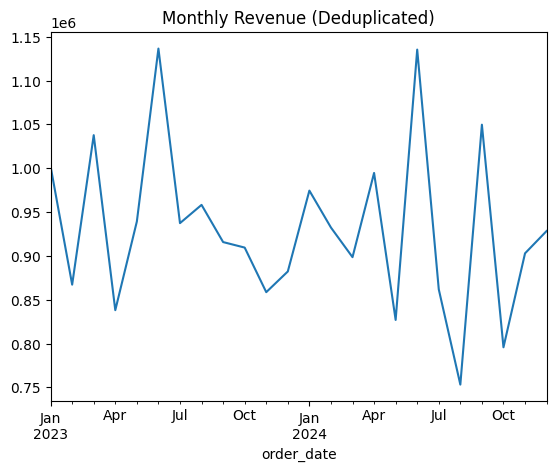

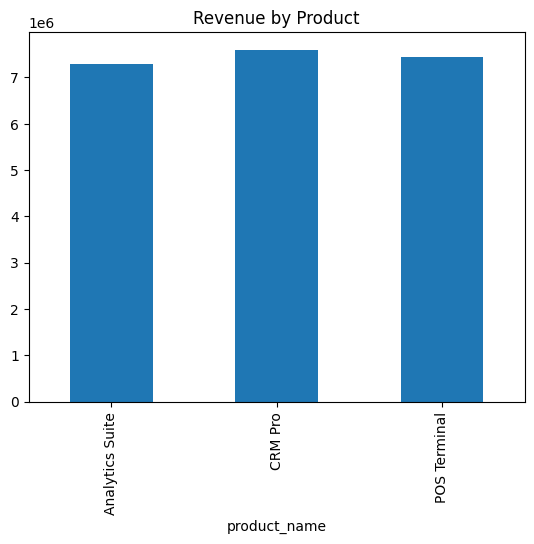

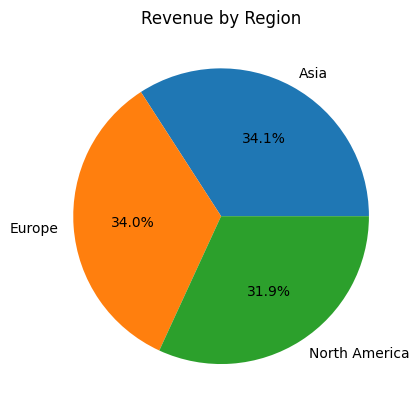

C:\Users\KRONOS\AppData\Local\Temp\ipykernel_49644\3088410879.py:58: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_id"]


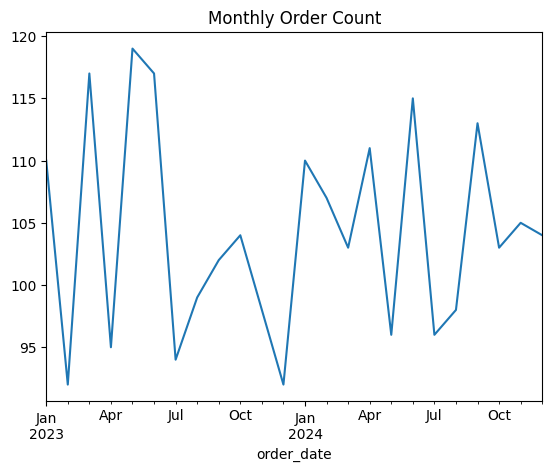

Average Revenue per Order: 8934.7864


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_duplicates.csv", parse_dates=["order_date"])

# ---------------------------
# Deduplication step (gold truth)
# ---------------------------
dedup = (
    df.sort_values("order_date")
      .drop_duplicates(subset=["order_id"], keep="first")
)

# ---------------------------
# KPI 1: Total Revenue (Deduped)
# ---------------------------
total_revenue = dedup["revenue"].sum()
print("Total Revenue (Deduplicated):", total_revenue)

# ---------------------------
# KPI 2: Duplicate Rate
# ---------------------------
duplicate_rate = 1 - (len(dedup) / len(df))
print("Duplicate Rate:", duplicate_rate)

# ---------------------------
# Trend 1: Monthly Revenue (Correct)
# ---------------------------
monthly_revenue = (
    dedup.set_index("order_date")
         .resample("M")["revenue"]
         .sum()
)

monthly_revenue.plot(title="Monthly Revenue (Deduplicated)")
plt.show()

# ---------------------------
# Trend 2: Revenue by Product
# ---------------------------
product_revenue = dedup.groupby("product_name")["revenue"].sum()
product_revenue.plot(kind="bar", title="Revenue by Product")
plt.show()

# ---------------------------
# Trend 3: Revenue by Region
# ---------------------------
region_revenue = dedup.groupby("region")["revenue"].sum()
region_revenue.plot(kind="pie", autopct="%1.1f%%", title="Revenue by Region")
plt.ylabel("")
plt.show()

# ---------------------------
# Trend 4: Orders Over Time
# ---------------------------
monthly_orders = (
    dedup.set_index("order_date")
         .resample("M")["order_id"]
         .count()
)

monthly_orders.plot(title="Monthly Order Count")
plt.show()

# ---------------------------
# KPI 3: Average Revenue per Order
# ---------------------------
avg_order_value = dedup["revenue"].mean()
print("Average Revenue per Order:", avg_order_value)
